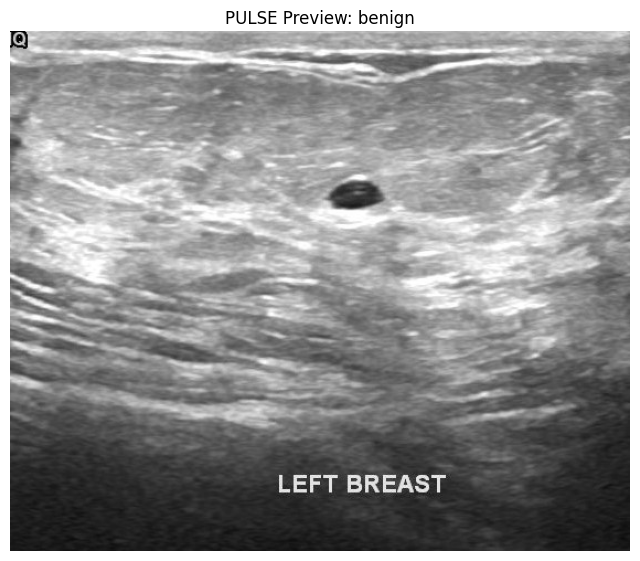

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define your external path (Adjust the drive/user if necessary)
data_root = "C:/Users/asmaa/Desktop/BUSI/Dataset_BUSI_with_GT" # Use your actual path here

# 2. Pick a category and an image
category = "benign"
img_name = "benign (1).png"
img_path = os.path.join(data_root, category, img_name)

# 3. Load and display
if os.path.exists(img_path):
    img = Image.open(img_path).convert('RGB')
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"PULSE Preview: {category}")
    plt.axis('off')
    plt.show()
else:
    print(f"Path not found! Check your path: {img_path}")

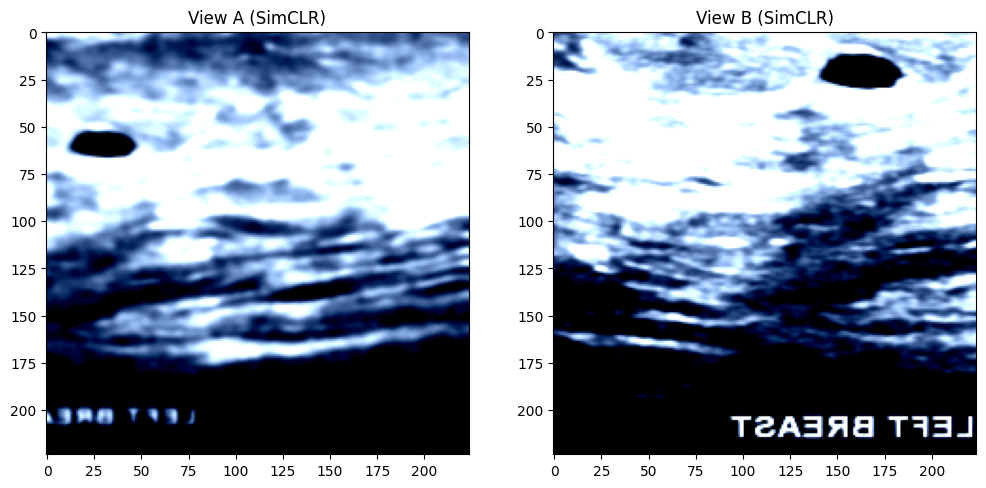

In [7]:
import sys
import os

# This adds the parent directory (PULSE root) to the system path
sys.path.append(os.path.abspath(os.path.join('..')))

from augmentations.ssl_transforms import SimCLRAugment

# 1. Initialize your custom augmenter
augmenter = SimCLRAugment(size=224)

# 2. Get the two views
view1, view2 = augmenter(img)

# 3. Plot them side-by-side
# We need to un-normalize or permute to view correctly
def denormalize(tensor):
    # Just a quick way to view for now
    return tensor.permute(1, 2, 0).clamp(0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(denormalize(view1))
ax[0].set_title("View A (SimCLR)")
ax[1].imshow(denormalize(view2))
ax[1].set_title("View B (SimCLR)")
plt.show()